In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_dihedral_angles)=
# Get dihedral angles

*Calculating dihedral and torsional angles from atom quartets.*

The function {func}`molsysmt.structure.get_dihedral_angles` calculates dihedral angles defined by four consecutively bonded atoms $(A, B, C, D)$, measuring the angle between planes $(A, B, C)$ and $(B, C, D)$.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_dihedral_angles`.
:::


## Basic usage

Let's measure the backbone $\phi$ dihedral angles of Met-enkephalin:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Met-enkephalin']['met_enkephalin.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We query the backbone $\phi$ atom quartets using {func}`molsysmt.topology.get_dihedral_quartets` and calculate their angles:


In [4]:
phi_quartets = msm.topology.get_dihedral_quartets(molsys, phi=True)
phi_angles = msm.structure.get_dihedral_angles(molsys, dihedral_quartets=phi_quartets)
print('Phi angles (degrees):', puw.convert(phi_angles, to_unit='degrees'))


Phi angles (degrees): [[-179.99977050951892 -179.9997685580422 -179.99976916196186  -179.99977065567504]] degree


## Measuring sidechain dihedral angles

In addition to backbone angles, sidechain torsional angles (such as $\chi_1, \chi_2$) or custom quartets can be queried and evaluated:


In [5]:
chi1_quartets = msm.topology.get_dihedral_quartets(molsys, chi1=True)
chi1_angles = msm.structure.get_dihedral_angles(molsys, dihedral_quartets=chi1_quartets)
print(f'Identified {len(chi1_quartets)} chi1 quartets.')
print('Chi1 dihedral angles (degrees):', puw.convert(chi1_angles, to_unit='degrees'))


Identified 3 chi1 quartets.
Chi1 dihedral angles (degrees): [[-179.99988816868782 -179.99988283064798 -179.99992497471675]] degree


## Ramachandran conformational distribution across structural ensembles

By computing backbone $\phi$ and $\psi$ dihedral angles across an ensemble of structures, we can map the conformational space onto a classic 2D Ramachandran plot:


In [6]:
traj = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])
phi_q = msm.topology.get_dihedral_quartets(traj, phi=True)
psi_q = msm.topology.get_dihedral_quartets(traj, psi=True)

phi_vals = msm.structure.get_dihedral_angles(traj, dihedral_quartets=phi_q[1])
psi_vals = msm.structure.get_dihedral_angles(traj, dihedral_quartets=psi_q[1])

phi_deg = puw.get_value(puw.convert(phi_vals[:, 0], to_unit='degrees'))
psi_deg = puw.get_value(puw.convert(psi_vals[:, 0], to_unit='degrees'))


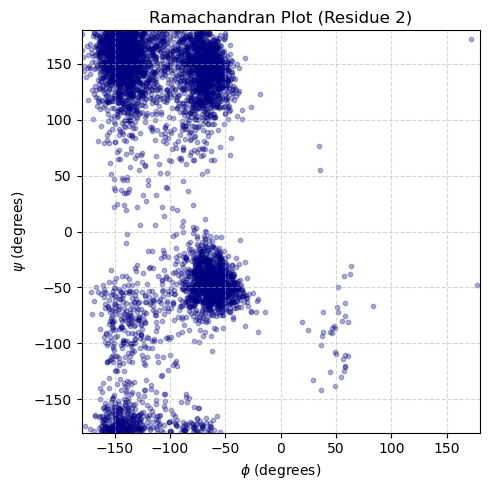

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(phi_deg, psi_deg, alpha=0.3, s=10, c='navy')
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xlabel('$\\phi$ (degrees)')
ax.set_ylabel('$\\psi$ (degrees)')
ax.set_title('Ramachandran Plot (Residue 2)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get dihedral quartets <Tutorial_Get_dihedral_quartets>`: Identify atom quartets for dihedral angles with {func}`molsysmt.topology.get_dihedral_quartets`.
- {ref}`Set dihedral angles <Tutorial_Set_dihedral_angles>`: Set dihedral angles to target values with {func}`molsysmt.structure.set_dihedral_angles`.
- {ref}`Shift dihedral angles <Tutorial_Shift_dihedral_angles>`: Increment or decrement dihedral angles with {func}`molsysmt.structure.shift_dihedral_angles`.
:::
